### Setup and Data

We generate two interlocking moon shapes.

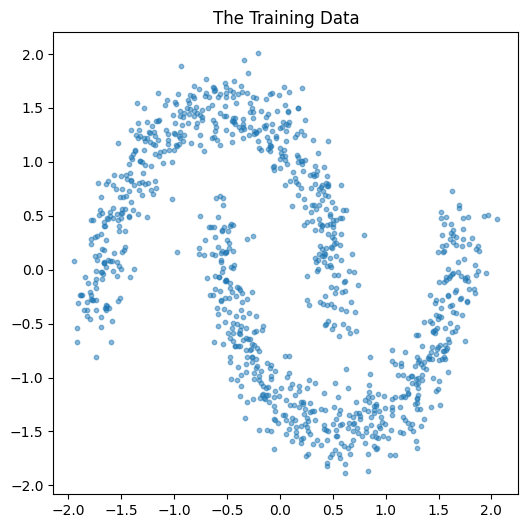

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 1. Prepare Data (The Two Moons)
# We generate 1000 points in a 'double moon' shape
data, _ = make_moons(n_samples=1000, noise=0.1)

# Normalize data to be roughly between -2 and 2 for stability
data = (data - data.mean(axis=0)) / data.std(axis=0)
dataset = torch.tensor(data, dtype=torch.float32)

# Visualize
plt.figure(figsize=(6, 6))
plt.scatter(dataset[:,0], dataset[:,1], s=10, alpha=0.5)
plt.title("The Training Data")
plt.show()

In [ ]:
dataset.shape

torch.Size([1000, 2])

###The Model & The Loss

Here is the critical part. We implement Hyvärinen's Score Matching Loss. Note: This requires calculating the derivative of the model's output with respect to its input (the Jacobian). This is computationally heavier than standard training, which is why Denoising Score Matching later became more popular.

In [ ]:
# 2. The Score Network (A simple MLP)
class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Softplus(), # Softplus is smoother than ReLU (better for second derivatives)
            nn.Linear(64, 64),
            nn.Softplus(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

# 3. Hyvärinen's Score Matching Loss
def score_matching_loss(model, x):
    # We need to track gradients w.r.t input x
    x.requires_grad_(True)

    # 1. Get the model's predicted score
    score_pred = model(x)

    # 2. Calculate the Divergence (Trace of Jacobian)
    # We need d(score)/dx. This requires a bit of autograd magic.

    # Derivative of x-component of score w.r.t x-input
    grad_s1 = torch.autograd.grad(score_pred[:,0].sum(), x, create_graph=True)[0][:,0]

    # Derivative of y-component of score w.r.t y-input
    grad_s2 = torch.autograd.grad(score_pred[:,1].sum(), x, create_graph=True)[0][:,1]

    # Trace = sum of diagonal elements (divergence)
    trace_jacobian = grad_s1 + grad_s2

    # 3. Calculate Norm Squared
    norm_sq = 0.5 * torch.sum(score_pred**2, dim=1)

    # 4. Final Hyvärinen Loss: Trace + 1/2 Norm^2
    loss = trace_jacobian + norm_sq

    return loss.mean()

### Training Loop

We train the model. Watch the loss go down.

Training...
Epoch 0: Loss 0.0528
Epoch 200: Loss -18.8902
Epoch 400: Loss -22.6029
Epoch 600: Loss -26.0166
Epoch 800: Loss -28.5463


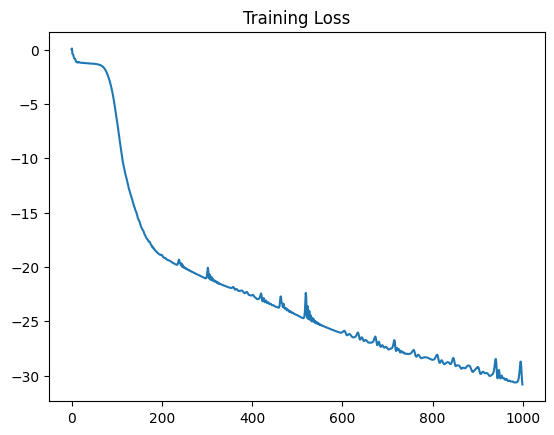

In [ ]:
# Initialize
model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train
loss_history = []
print("Training...")
for epoch in range(1000): # 1000 steps
    optimizer.zero_grad()

    # Calculate loss on the whole dataset (batch gradient descent)
    loss = score_matching_loss(model, dataset)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.4f}")

plt.plot(loss_history)
plt.title("Training Loss")
plt.show()

### Evaluate (Visualize the Learned Field)

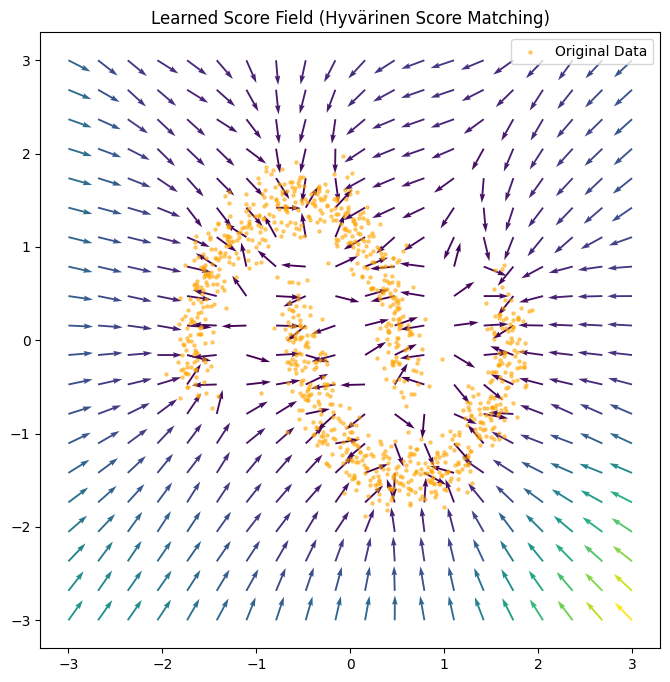

In [ ]:
# Create a grid
x_range = np.linspace(-3, 3, 20)
y_range = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x_range, y_range)

grid_pts = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)

# Get predictions from our trained model
with torch.no_grad():
    scores = model(grid_pts).numpy()

U = scores[:, 0].reshape(X.shape)
V = scores[:, 1].reshape(Y.shape)

# Plot
plt.figure(figsize=(8, 8))
plt.title("Learned Score Field (Hyvärinen Score Matching)")

# 1. Plot the vector field
# Normalize arrows for cleaner look
norms = np.sqrt(U**2 + V**2)
plt.quiver(X, Y, U/norms, V/norms, norms, cmap='viridis', scale=25)

# 2. Plot the original data
# FIX IS HERE: Added .detach() before .numpy() (or implicit conversion)
plt.scatter(dataset.detach()[:,0], dataset.detach()[:,1], s=5, color='orange', alpha=0.5, label='Original Data')

plt.legend()
plt.show()

### Sampling using Langevin Dynamics

Let us now use Langevin Dynamics to generate samples using the learnt score function

Sampling...


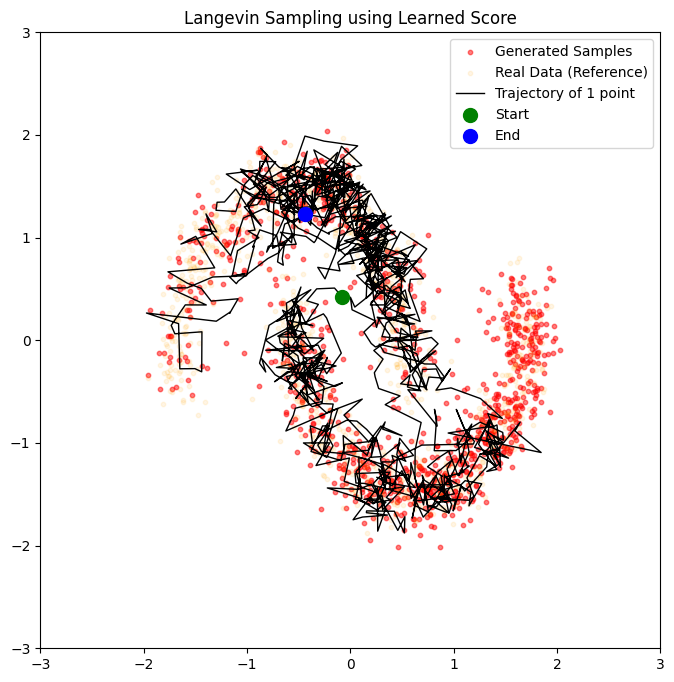

In [ ]:
# 1. Langevin Dynamics Parameters
n_steps = 1000       # How many steps to refine the noise
eta = 0.01           # Step size (Learning rate for the sampling)
noise_scale = np.sqrt(2 * eta) # Scale of the random noise term

# 2. Initialize Random Noise (The "Latent" Space)
# We start with points scattered uniformly in the box [-3, 3]
n_samples = 1000
samples = torch.rand(n_samples, 2) * 6 - 3  # Uniform [-3, 3]

# 3. The Sampling Loop
print("Sampling...")
model.eval() # Set model to evaluation mode (good practice)

# We want to visualize the path of ONE specific point to see the "walk"
# Let's track the first point in our batch
path_x = [samples[0,0].item()]
path_y = [samples[0,1].item()]

for i in range(n_steps):
    # A. Calculate the Score (using our TRAINED NEURAL NET)
    # We don't need gradients for the sampling process itself
    with torch.no_grad():
        pred_score = model(samples)

    # B. Generate Random Noise (Langevin noise)
    noise = torch.randn_like(samples)

    # C. Update Position
    # x_new = x + eta * score + sqrt(2*eta) * noise
    samples = samples + (eta * pred_score) + (noise_scale * noise)

    # Track the path of the first sample
    path_x.append(samples[0,0].item())
    path_y.append(samples[0,1].item())

# 4. Visualize
plt.figure(figsize=(8, 8))
plt.title("Langevin Sampling using Learned Score")

# Plot the FINAL positions of all 1000 samples
plt.scatter(samples[:,0], samples[:,1], s=10, color='red', alpha=0.5, label='Generated Samples')

# Plot the Original Data for comparison (faint orange)
plt.scatter(dataset.detach()[:,0], dataset.detach()[:,1], s=10, color='orange', alpha=0.1, label='Real Data (Reference)')

# Plot the trajectory of the ONE tracked point
plt.plot(path_x, path_y, color='black', linewidth=1, label='Trajectory of 1 point')
plt.scatter(path_x[0], path_y[0], c='green', s=100, label='Start', zorder=5)
plt.scatter(path_x[-1], path_y[-1], c='blue', s=100, label='End', zorder=5)

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

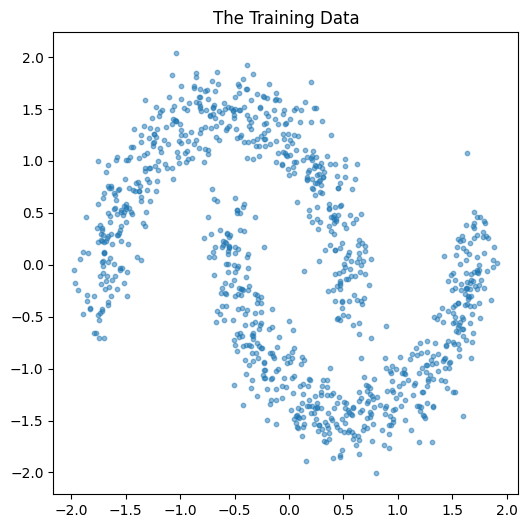

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 1. Prepare Data (The Two Moons)
# We generate 1000 points in a 'double moon' shape
data, _ = make_moons(n_samples=1000, noise=0.1)

# Normalize data to be roughly between -2 and 2 for stability
data = (data - data.mean(axis=0)) / data.std(axis=0)
dataset = torch.tensor(data, dtype=torch.float32)

# Visualize
plt.figure(figsize=(6, 6))
plt.scatter(dataset[:,0], dataset[:,1], s=10, alpha=0.5)
plt.title("The Training Data")
plt.show()

In [2]:
class ScoreNet(nn.Module):

  def __init__(self):
    self.score_net = nn.Sequential(
        nn.Linear(2, 64),
        nn.Softplus(),
        nn.Linear(64, 64),
        nn.Softplus(),
        nn.Linear(64, 2)
    )

  def forward(self, x):
    score = self.score_net(x)
    return score


In [3]:
def score_matching_loss(model, x):
  x.requires_grad_(True)
  score_pred = model(x)
  # Derivative of x-component of score w.r.t x-input
  grad_s1 = torch.autograd.grad(score_pred[:,0].sum(), x, create_graph=True)[0][:,0]

  # Derivative of y-component of score w.r.t y-input
  grad_s2 = torch.autograd.grad(score_pred[:,1].sum(), x, create_graph=True)[0][:,1]

  # Trace = sum of diagonal elements (divergence)
  trace_jacobian = grad_s1 + grad_s2

  # 3. Calculate Norm Squared
  norm_sq = 0.5 * torch.sum(score_pred**2, dim=1)

  # 4. Final Hyvärinen Loss: Trace + 1/2 Norm^2
  loss = trace_jacobian + norm_sq

  return loss.mean()
